## America Express Stock Analysis

### Data loading and visualization

In [1]:
# Imports
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
from utils import plot_series, XGBModel, LinearRegressionModel
import warnings

# Supprimer tous les warnings
warnings.filterwarnings('ignore')

In [2]:
file_path = "data/AXP_stock_data.csv"

# Load the CSV file into a DataFrame
df = pd.read_csv(file_path)
df["Date"] = pd.to_datetime(df["Date"], utc=True)
df.set_index("Date", inplace=True)
df = df.tz_convert("America/New_York").tz_localize(None)
df

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Daily_Return,Cumulative_Return,MA_50,MA_200
Date,,,,,,,,,,,
2010-01-04,32.467961,32.698679,32.133812,32.555473,6894300,0.00,0.0,NaN,NaN,NaN,NaN
2010-01-05,32.483875,32.802109,32.117902,32.483875,10641200,0.00,0.0,-0.002199,-0.002199,NaN,NaN
2010-01-06,32.802106,33.152164,32.754370,33.008961,8399400,0.00,0.0,0.016164,0.013930,NaN,NaN
2010-01-07,32.969006,33.752083,32.849150,33.544327,8981700,0.18,0.0,0.016219,0.030374,NaN,NaN
2010-01-08,33.368525,33.943846,33.080868,33.520348,7907700,0.00,0.0,-0.000715,0.029638,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2025-12-08,369.910004,370.000000,360.700012,362.279999,2581400,0.00,0.0,-0.021790,10.128083,350.513572,308.133874
2025-12-09,363.029999,368.070007,362.500000,363.910004,2197600,0.00,0.0,0.004499,10.178151,350.962876,308.488085
2025-12-10,363.000000,377.980011,363.000000,375.570007,2804400,0.00,0.0,0.032041,10.536309,351.847866,308.911455


In [3]:
plot_series(df.index, {"Close": df["Close"]}, "AXP Stock Closing Prices")

### Analyse de la série temporelle

Dans cette section, nous allons décomposer la série temporelle pour identifier les tendances, saisonnalités et résidus. Nous examinerons également les fonctions d'autocorrélation (ACF) et d'autocorrélation partielle (PACF) pour comprendre la structure de dépendance temporelle.

In [4]:
# Decompose the serie to see trend and seasonality and residuals
decomposition = seasonal_decompose(df["Close"], model="additive", period=7)

plot_series(
    index=decomposition.trend.index,
    y_values_dict={
        "Trend": decomposition.trend,
        "Seasonality": decomposition.seasonal,
        "Residuals": decomposition.resid,
    },
    title="Decomposition of AXP Stock Closing Prices",
)

#### Test Dickey-Fuller pour vérifier la stationnarité de la série

In [6]:
# Test de Dickey-Fuller pour la stationnarité
from statsmodels.tsa.stattools import adfuller
result = adfuller(df["Close"].dropna())
print('ADF Statistic:', result[0])
print('p-value:', result[1])
for key, value in result[4].items():
    print('Critical Values:')
    print(f'   {key}, {value}')

ADF Statistic: 2.8904758495251515
p-value: 1.0
Critical Values:
   1%, -3.4319941011564126
Critical Values:
   5%, -2.862266473956485
Critical Values:
   10%, -2.567156709994697


### Différenciation de la série

Nous appliquons une différenciation d'ordre 1 pour stationnariser la série temporelle, ce qui est nécessaire pour certains modèles comme ARIMA.

In [7]:
# Plot de la série différenciée à l'ordre 1 avec plotly
df_diff = df["Close"].diff().dropna()

plot_series(df_diff.index, {"Differenced Close": df_diff}, "AXP Stock Closing Prices - First Difference")

In [13]:
# Test de Dickey-Fuller pour la stationnarité
result = adfuller(df_diff.dropna())
print('ADF Statistic:', result[0])
print('p-value:', result[1])
for key, value in result[4].items():
    print('Critical Values:')
    print(f'   {key}, {value}')

ADF Statistic: -12.024302568087192
p-value: 2.9735562166510915e-22
Critical Values:
   1%, -3.4319941011564126
Critical Values:
   5%, -2.862266473956485
Critical Values:
   10%, -2.567156709994697


#### Analyse PACF et ACF

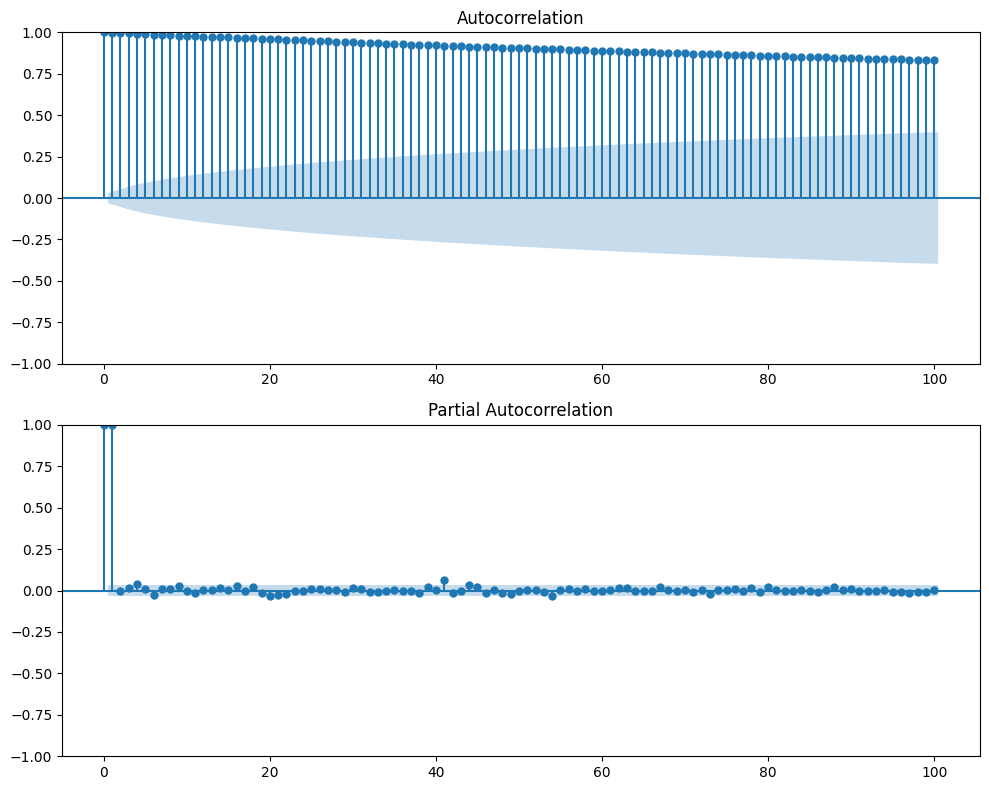

In [16]:

fig, ax = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(df["Close"].dropna(), lags=100, ax=ax[0])
plot_pacf(df["Close"].dropna(), lags=100, ax=ax[1])
plt.tight_layout()
plt.show()

### Division des données en ensembles d'entraînement et de test

Nous séparons les données en 80% pour l'entraînement et 20% pour le test. Cette division nous permettra d'évaluer la performance des modèles sur des données non vues.

In [18]:
# Séparation de la série en ensembles d'entraînement et de test
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

# Create a train_plot and test_plot dataframes where data from index train_size onward is NaN for train_plot and data before train_size is NaN for test_plot
train_plot = pd.concat([train, pd.DataFrame(index=test.index, columns=df.columns)], axis=0)
test_plot = pd.concat([pd.DataFrame(index=train.index, columns=df.columns), test], axis=0)

plot_series(
    index=df.index,
    y_values_dict={
        "Train": train_plot["Close"],
        "Test": test_plot["Close"],
    },
    title="AXP Stock Closing Prices - Train/Test Split",
)

### Entraînement des modèles et prédictions

Dans cette section, nous entraînons trois modèles différents : ARIMA, XGBoost et Régression Linéaire. Pour optimiser le temps d'exécution, nous réentraînons les modèles tous les 7 jours (au lieu de chaque jour), puis nous utilisons ces modèles pour prédire les jours suivants jusqu'au prochain réentraînement. Cela simule un scénario réaliste où nous mettons à jour nos modèles de manière hebdomadaire.

In [23]:
arima_predictions = []
xgb_predictions = []
linreg_predictions = []

# Initialiser les modèles (seront réentraînés tous les 7 jours)
arima_model = None
xgb_model = None
linreg_model = None

# Fréquence de réentraînement (en jours)
retrain_frequency = 28

# Pour chaque point de test, prédire (et réentraîner si nécessaire)
for i in range(len(test)-1):
    if i % retrain_frequency == 0:
        # Créer un ensemble d'entraînement dynamique incluant toutes les données jusqu'à l'index actuel
        train_dynamic = df.iloc[:train_size + i]
        
        print(f"Réentraînement au jour {i}/{len(test)}...")
        
        # ARIMA: entraîner
        arima_model = ARIMA(train_dynamic["Close"], order=(1, 1, 0)).fit()
        
        # XGBoost: entraîner
        xgb_model = XGBModel()
        xgb_model.fit(train_dynamic[["Close"]])
        
        # Régression Linéaire: entraîner
        linreg_model = LinearRegressionModel()
        linreg_model.fit(train_dynamic[["Close"]])
    
    # Prédire avec les modèles actuels
    arima_pred = arima_model.forecast(steps=1).values[0]
    arima_predictions.append(arima_pred)
    
    xgb_pred = xgb_model.predict(X_test=df.iloc[train_size+i-1: train_size+i+1][["Close"]])
    xgb_predictions.append(xgb_pred)
    
    linreg_pred = linreg_model.predict(X_test=df.iloc[train_size+i-1: train_size+i+1][["Close"]])
    linreg_predictions.append(linreg_pred)

print("Prédictions terminées!")

# Créer des DataFrames pour les prédictions
arima_predictions_series = pd.Series(arima_predictions, index=test.index[:-1], name="Close")
xgb_predictions_series = pd.Series(xgb_predictions, index=test.index[:-1], name="Close")
linreg_predictions_series = pd.Series(linreg_predictions, index=test.index[:-1], name="Close")

Réentraînement au jour 0/803...
Réentraînement au jour 28/803...
Réentraînement au jour 56/803...
Réentraînement au jour 84/803...
Réentraînement au jour 112/803...
Réentraînement au jour 140/803...
Réentraînement au jour 168/803...
Réentraînement au jour 196/803...
Réentraînement au jour 224/803...
Réentraînement au jour 252/803...
Réentraînement au jour 280/803...
Réentraînement au jour 308/803...
Réentraînement au jour 336/803...
Réentraînement au jour 364/803...
Réentraînement au jour 392/803...
Réentraînement au jour 420/803...
Réentraînement au jour 448/803...
Réentraînement au jour 476/803...
Réentraînement au jour 504/803...
Réentraînement au jour 532/803...
Réentraînement au jour 560/803...
Réentraînement au jour 588/803...
Réentraînement au jour 616/803...
Réentraînement au jour 644/803...
Réentraînement au jour 672/803...
Réentraînement au jour 700/803...
Réentraînement au jour 728/803...
Réentraînement au jour 756/803...
Réentraînement au jour 784/803...
Prédictions terminé

In [24]:
# Créer les dataframes pour les plots
arima_plot = pd.concat([pd.Series(index=train.index, name="Close"), arima_predictions_series], axis=0)
xgb_plot = pd.concat([pd.Series(index=train.index, name="Close"), xgb_predictions_series], axis=0)
linreg_plot = pd.concat([pd.Series(index=train.index, name="Close"), linreg_predictions_series], axis=0)

# Visualisation complète de la série temporelle
plot_series(
    index=df.index,
    y_values_dict={
        "Train": train_plot["Close"],
        "Test": test_plot["Close"],
        "ARIMA Predictions": arima_plot,
        "XGBoost Predictions": xgb_plot,
        "Linear Regression Predictions": linreg_plot,
    },
    title=f"AXP Stock Closing Prices - Comparaison des Modèles (Réentraînement tous les {retrain_frequency} jours)",
)

In [25]:
# Calcule des métriques d'évaluation (MAE, RMSE, MAPE, R²)
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score, mean_absolute_percentage_error

arima_mae = mean_absolute_error(test["Close"][:-1], arima_predictions_series)
arima_rmse = root_mean_squared_error(test["Close"][:-1], arima_predictions_series)
arima_r2 = r2_score(test["Close"][:-1], arima_predictions_series)
arima_mape = mean_absolute_percentage_error(test["Close"][:-1], arima_predictions_series)*100

xgb_mae = mean_absolute_error(test["Close"][:-1], xgb_predictions_series)
xgb_rmse = root_mean_squared_error(test["Close"][:-1], xgb_predictions_series)
xgb_r2 = r2_score(test["Close"][:-1], xgb_predictions_series)
xgb_mape = mean_absolute_percentage_error(test["Close"][:-1], xgb_predictions_series)*100

linreg_mae = mean_absolute_error(test["Close"][:-1], linreg_predictions_series)
linreg_rmse = root_mean_squared_error(test["Close"][:-1], linreg_predictions_series)
linreg_r2 = r2_score(test["Close"][:-1], linreg_predictions_series)
linreg_mape = mean_absolute_percentage_error(test["Close"][:-1], linreg_predictions_series)*100

# Affichage des résultats dans un dataframe
results_df = pd.DataFrame({
    "Model": ["ARIMA", "XGBoost", "Linear Regression"],
    "MAE": [arima_mae, xgb_mae, linreg_mae],
    "RMSE": [arima_rmse, xgb_rmse, linreg_rmse],
    "R²": [arima_r2, xgb_r2, linreg_r2],
    "MAPE (%)": [arima_mape, xgb_mape, linreg_mape],
})
results_df

,Model,MAE,RMSE,R²,MAPE (%)
0,ARIMA,9.541256,13.676263,0.960491,4.112340
1,XGBoost,9.269500,15.823155,0.947114,3.649283
2,Linear Regression,2.750564,4.115744,0.996422,1.219523
